# SDG Project - Analisi Esplorativa del Dataset
- Caricamento del dataset
- Descrizione del dataset
- Data Cleaning (gestione dei missing values) 
- 

In [1]:
# Import delle librerie principali
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Caricamento dei dataset
# Nota: dataset.csv utilizza ';' come separatore e ',' come separatore decimale per i valori numerici
df = pd.read_csv('dataset/dataset.csv', sep=';', decimal=',')
data_desc = pd.read_csv('dataset/data_descriptions.csv', sep=';')

print("Dataset caricati con successo!")

Dataset caricati con successo!


### 1. Descrizione dataset 
Verifichiamo la dimensione complessiva del dataset (numero di righe e colonne) e analizziamo i tipi di dato (`dtypes`) associati a ciascuna colonna.
Separiamo le colonne del dataset in **categoriche** (identificate dal tipo `object`/`string` o dal prefisso `text_format` nelle descrizioni) e **numeriche**. Eseguiamo infine `.describe()` separatamente per i due gruppi.

In [ ]:
from IPython.display import display
# 1. Shape del dataset (righe, colonne)
print(f"Shape del dataset: {df.shape[0]} righe, {df.shape[1]} colonne\n")

# Prime 5 righe
print("--- Prime 5 righe del dataset ---")
display(df.head())

# Tipi di dato delle colonne (dtypes)
# print("\n--- Tipi di dato (dtypes) - Prime 20 colonne ---")
# display(df.dtypes.to_frame(name='dtype').head(20))

# Elenco variabili con prefisso text_format nelle descrizioni
tf_vars = set(data_desc[data_desc['Variable'].astype(str).str.startswith('text_format')]['Variable'].astype(str).str.replace('text_format', '').str.lower())

# Classificazione colonne categoriche vs numeriche
cat_cols = [c for c in df.columns if str(df[c].dtype) in ['object', 'string', 'str'] or c.lower() in tf_vars]
num_cols = [c for c in df.columns if c not in cat_cols]

print(f"Numero Colonne Categoriche: {len(cat_cols)}")
# print(f"Colonne Categoriche: {cat_cols}\n")
print(f"Numero Colonne Numeriche: {len(num_cols)}\n")

# print("--- Describe Colonne Numeriche (Prime 10) ---")
# display(df[num_cols].describe().T.head(10))

# print("\n--- Describe Colonne Categoriche ---")
# display(df[cat_cols].describe().T)

# Numero di categorie uniche per ogni colonna categorica
cat_summary = pd.DataFrame({
    'colonna': cat_cols,
    'n_categorie': [df[c].nunique(dropna=True) for c in cat_cols],
    'n_missing': [df[c].isna().sum() for c in cat_cols]
}).sort_values('n_categorie', ascending=False).reset_index(drop=True)

print(f"--- Numero di categorie per ciascuna delle {len(cat_cols)} colonne categoriche ---")
display(cat_summary)

for c in cat_cols:
    n = df[c].nunique(dropna=True)
    if n <= 15:  # mostra i valori solo se sono "gestibili"
        print(f"{c} ({n} categorie): {sorted(df[c].dropna().unique().tolist())}")
    else:
        print(f"{c} ({n} categorie): troppe per l'elenco, es. {df[c].dropna().unique()[:5].tolist()}...")

### 2. Distribuzione della Colonna Target "churn"
Analizziamo la distribuzione della variabile target `churn` sia in termini di frequenza assoluta che percentuale, per verificare il bilanciamento delle classi (presenza di eventuale class imbalance).
Classe 1 clienti abbandonano il servizio, classe 0 no.

In [ ]:
# Conteggio assoluto e percentuale della variabile target churn
churn_counts = df['churn'].value_counts(dropna=False)
churn_pct = df['churn'].value_counts(normalize=True, dropna=False) * 100

churn_dist = pd.DataFrame({
    'Conteggio Assoluto': churn_counts,
    'Percentuale (%)': churn_pct.round(2)
})

display(churn_dist)

# Valutazione del bilanciamento
pct_0, pct_1 = churn_pct.get(0, 0), churn_pct.get(1, 0)
print(f"\nDistribuzione target: Classe 0 = {pct_0:.2f}%, Classe 1 = {pct_1:.2f}%")
if abs(pct_0 - pct_1) < 10:
    print("Esito: La variabile target 'churn' risulta perfettamente bilanciata (~50% vs ~50%).")
else:
    print("Esito: La variabile target 'churn' risulta sbilanciata.")

### 3. Splitto il dataset in train e test
Lo suddivido in modo randomico 70% train e 30% test. 
La popolazione è rappresentata in entrambi i dataset? Dovrei suddividere bilanciando la classe churn nei due dataset?

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# Creo una copia di df da usare per lo split
df_clean = df.copy()

# # Controllo il formato delle colonne 
# print(df_clean.dtypes)

#Imposto Customer_ID come colonna indice 
df_clean = df_clean.set_index('Customer_ID')

# Split in train e test set
X = df_clean.drop(columns=['churn'])  
y = df_clean['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_train_model, X_val, y_train_model, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.15,
    random_state=42,
    stratify=y_train
)

# Numero di righe in train e test set
print(f"Dimensione training set: {X_train_model.shape[0]} righe")
print(f"Dimensione validation set: {X_val.shape[0]} righe")
print(f"Dimensione test set: {X_test.shape[0]} righe")

Dimensione training set: 59500 righe
Dimensione validation set: 10500 righe
Dimensione test set: 30000 righe


### 4. Analisi dei Missing Values (MVs)
Calcoliamo il numero di missing values (`null/NaN`) per ciascuna colonna.
L'output è ordinato in modo decrescente e include esclusivamente le colonne con un numero di valori mancanti superiore a zero (`missing > 0`).

Impostiamo una soglia del 30% e attuiamo la strategia di gestione dei MVs:

**Numeriche**
MVs > 30%: Rimozione colonna
MVs < 30%: Imputazione con mediana

**Categoriche**
Categoria ‘MISSING’


In [5]:
import pandas as pd
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin

class MissingValueHandler(BaseEstimator, TransformerMixin):
    """
    Gestisce i missing values secondo la strategia:
    - Colonne numeriche/categoriche con MVs > soglia: rimosse
    - Colonne numeriche con MVs <= soglia: imputate con la mediana (calcolata sul train)
    - Colonne categoriche con MVs <= soglia: imputate con 'MISSING'
    """
    def __init__(self, threshold=30):
        self.threshold = threshold

    def fit(self, X, y=None):
        X = X.copy()
        missing_pct = (X.isnull().sum() / len(X)) * 100
        num_cols = X.select_dtypes(include=[np.number]).columns
        cat_cols = X.select_dtypes(include=['object', 'string']).columns

        num_gt30 = missing_pct[(missing_pct.index.isin(num_cols)) & (missing_pct > self.threshold)]
        cat_gt30 = missing_pct[(missing_pct.index.isin(cat_cols)) & (missing_pct > self.threshold)]

        self.cols_to_drop_ = num_gt30.index.tolist() + cat_gt30.index.tolist()

        remaining_num_cols = [c for c in num_cols if c not in self.cols_to_drop_]
        self.medians_ = {col: X[col].median() for col in remaining_num_cols}
        self.remaining_cat_cols_ = [c for c in cat_cols if c not in self.cols_to_drop_]

        return self

    def transform(self, X):
        X = X.copy()
        X = X.drop(columns=[c for c in self.cols_to_drop_ if c in X.columns])
        for col, median_value in self.medians_.items():
            if col in X.columns:
                X[col] = X[col].fillna(median_value)
        for col in self.remaining_cat_cols_:
            if col in X.columns:
                X[col] = X[col].fillna('MISSING')
        return X


from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import OneHotEncoder

# Usiamo make_column_selector per selezionare le colonne categoriche dinamicamente
# DOPO l'esecuzione di MissingValueHandler nella Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            make_column_selector(dtype_include=['object', 'string']),
        )
    ],
    remainder='passthrough',  # le numeriche passano invariate
)


### 5. Random Forest
Voglio capire quali variabili sono più significative per il churn e lavorare su quelle.


In [ ]:
# ### 6. Pipeline completa: MissingValueHandler + Preprocessor + RandomForest
# from sklearn.pipeline import Pipeline
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.model_selection import StratifiedKFold, GridSearchCV

# full_pipeline = Pipeline([
#     ('missing_handler', MissingValueHandler(threshold=30)),
#     ('preprocessor', preprocessor),
#     ('rf', RandomForestClassifier(random_state=42, n_jobs=1))
# ])

# # --- Stratified K-Fold (k=5) ---
# skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# # --- Griglia di iperparametri del RF da esplorare ---
# param_grid = {
#     'rf__n_estimators': [200, 300],
#     'rf__max_depth': [5, 10, 15],
#     'rf__min_samples_leaf': [1, 5, 10],
#     'rf__min_samples_split': [2, 10, 20]
# }

# # --- Grid Search con cross-validation, prova tutte le ipercombinazioni---
# grid_search = GridSearchCV(
#     full_pipeline,
#     param_grid=param_grid,
#     cv=skf,
#     scoring='f1',       # metrica orientata a individuare bene la classe churn=1
#     n_jobs=-1,
#     verbose=2,
#     return_train_score=True  # utile per controllare l'overfitting per combinazione
# )

# # Fit: qui passiamo X_train "grezzo", NON processato a mano.
# # Il preprocessing viene rifatto da zero ad ogni fold, evitando data leakage.
# grid_search.fit(X_train, y_train)

# print("Migliori iperparametri trovati:")
# print(grid_search.best_params_)
# print(f"\nMiglior F1-score medio in CV: {grid_search.best_score_:.4f}")

# # --- Ispezione rapida dei risultati per controllare overfitting ---
# cv_results = pd.DataFrame(grid_search.cv_results_)
# cv_results_sorted = cv_results.sort_values('mean_test_score', ascending=False)
# display(cv_results_sorted[[
#     'param_rf__n_estimators', 'param_rf__max_depth',
#     'param_rf__min_samples_leaf', 'param_rf__min_samples_split',
#     'mean_train_score', 'mean_test_score', 'std_test_score'
# ]].head(10))


# ### 7. Valutazione finale sul TEST set (mai toccato finora)
# best_model = grid_search.best_estimator_

# # best_model è già rifittato su TUTTO X_train con i migliori iperparametri
# y_pred_test = best_model.predict(X_test)
# y_proba_test = best_model.predict_proba(X_test)[:, 1]

# from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# print("Accuracy su train (best_model):", best_model.score(X_train, y_train))
# print("Accuracy su test (best_model):", best_model.score(X_test, y_test))
# print(f"\nROC-AUC su test: {roc_auc_score(y_test, y_proba_test):.4f}")
# print("\n--- Classification Report (test set) ---")
# print(classification_report(y_test, y_pred_test))
# print("\n--- Confusion Matrix (test set) ---")
# print(confusion_matrix(y_test, y_pred_test))

CONTROLLO F1 SCORE ANCHE SUL TRAIN E CONFRONTO PER CONFERMARE O NO OVERFITTING

In [ ]:
# from sklearn.metrics import f1_score

# y_pred_train = best_model.predict(X_train)
# y_pred_test = best_model.predict(X_test)

# print("Train F1:", f1_score(y_train, y_pred_train))
# print("Test F1:", f1_score(y_test, y_pred_test))

Provo ad agire sulla sogli

In [ ]:
# from sklearn.metrics import precision_score, recall_score, f1_score
# import numpy as np
# import pandas as pd

# thresholds = np.arange(0.10, 0.91, 0.05)

# results = []

# for threshold in thresholds:
    
#     y_pred = (y_proba_test >= threshold).astype(int)
    
#     results.append({
#         'threshold': threshold,
#         'precision': precision_score(y_test, y_pred),
#         'recall': recall_score(y_test, y_pred),
#         'f1': f1_score(y_test, y_pred)
#     })

# threshold_results = pd.DataFrame(results)

# display(threshold_results)

ANALISI SULLE SOGLIE DI CLASSIFICAZIONE PER RANDOM FOREST


In [ ]:
# optimal_threshold = 0.40
# y_pred_optimal = (y_proba_test >= optimal_threshold).astype(int)

# from sklearn.metrics import classification_report, confusion_matrix
# print(classification_report(y_test, y_pred_optimal))
# print(confusion_matrix(y_test, y_pred_optimal))

In [ ]:
# optimal_threshold = 0.45
# y_pred_optimal = (y_proba_test >= optimal_threshold).astype(int)

# from sklearn.metrics import classification_report, confusion_matrix
# print(classification_report(y_test, y_pred_optimal))
# print(confusion_matrix(y_test, y_pred_optimal))

## GRADIENT BOOSTING- per risolvere overfittiing e aumentare le performance

In [ ]:
### 8. Confronto con Gradient Boosting Classifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV


gb_pipeline = Pipeline([
    ('missing_handler', MissingValueHandler(threshold=30)),
    ('preprocessor', preprocessor),
    ('gb', GradientBoostingClassifier(random_state=42))
])

# # --- Stratified K-Fold (k=5) ---
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gb_param_grid = {
    'gb__n_estimators': [100, 200],
    'gb__max_depth': [3, 5],
    'gb__learning_rate': [0.05, 0.1]
}

gb_grid_search = GridSearchCV(
    gb_pipeline,
    param_grid=gb_param_grid,
    cv=skf,              #  StratifiedKFold 
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

gb_grid_search.fit(X_train_model, y_train_model)  

print("Migliori iperparametri GBM:")
print(gb_grid_search.best_params_)
print(f"Miglior roc_auc medio in CV: {gb_grid_search.best_score_:.4f}")

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Migliori iperparametri GBM:
{'gb__learning_rate': 0.1, 'gb__max_depth': 5, 'gb__n_estimators': 200}
Miglior F1-score medio in CV: 0.6843


In [8]:
print("Migliori iperparametri GBM:")
print(gb_grid_search.best_params_)
print(f"Miglior ROC-AUC medio in CV: {gb_grid_search.best_score_:.4f}")

Migliori iperparametri GBM:
{'gb__learning_rate': 0.1, 'gb__max_depth': 5, 'gb__n_estimators': 200}
Miglior ROC-AUC medio in CV: 0.6843


In [9]:
### 9. Predizioni sul validation set per la scelta della soglia

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score

gb_best_model = gb_grid_search.best_estimator_

# Probabilità sul validation set
y_proba_val_gb = gb_best_model.predict_proba(X_val)[:, 1]

print(f"ROC-AUC validation GBM: {roc_auc_score(y_val, y_proba_val_gb):.4f}")

ROC-AUC validation GBM: 0.6955


Lavoro sulle soglie di classificazione per aumentare le performance ottimizzando RECALL a discapito della precision -> preferisco falsi positivi che falsi negativi (?) 
Scelta da discutere

n.b 
precision = tp/(tp+fp)

recall=tp/(tp+fn)

In [10]:
### 10. Analisi soglie di decisione sul Gradient Boosting

from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.10, 0.95, 0.05)
results = []

for t in thresholds:
    y_pred_t = (y_proba_val_gb >= t).astype(int)

    precision = precision_score(y_val, y_pred_t, zero_division=0)
    recall = recall_score(y_val, y_pred_t, zero_division=0)
    f1 = f1_score(y_val, y_pred_t, zero_division=0)

    results.append({
        'threshold': round(t, 2),
        'precision': precision,
        'recall': recall,
        'f1': f1
    })

threshold_df_gb = pd.DataFrame(results)

display(threshold_df_gb)

# Soglia che massimizza F1 sul validation set
best_row = threshold_df_gb.loc[threshold_df_gb['f1'].idxmax()]

best_threshold_gb = best_row['threshold']

print(
    f"\nOptimal F1 threshold (validation): "
    f"{best_threshold_gb:.2f} (F1 = {best_row['f1']:.4f})"
)

,threshold,precision,recall,f1
0,0.10,0.496139,1.000000,0.663226
1,0.15,0.499135,0.997502,0.665342
2,0.20,0.509716,0.987894,0.672466
3,0.25,0.523928,0.967717,0.679806
4,0.30,0.539803,0.939470,0.685646
5,0.35,0.556652,0.899693,0.687771
6,0.40,0.579310,0.839354,0.685499
7,0.45,0.606388,0.755188,0.672657
8,0.50,0.636621,0.648732,0.642619
9,0.55,0.665516,0.518447,0.582847



Optimal F1 threshold (validation): 0.35 (F1 = 0.6878)


Confronto tra Random Forest e Gradient Boosting

In [11]:
# import matplotlib.pyplot as plt

# plt.figure(figsize=(10, 6))
# plt.plot(best_row['threshold'], threshold_results['f1'], marker='o', label='Random Forest')
# plt.plot(threshold_df_gb['threshold'], threshold_df_gb['f1'], marker='o', label='Gradient Boosting')
# plt.xlabel('Soglia di decisione')
# plt.ylabel('F1-score (classe churn)')
# plt.title('F1-score al variare della soglia: Random Forest vs Gradient Boosting')
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.4)
# plt.show()

In [14]:
### 11. Permutation Importance sul Gradient Boosting

from sklearn.inspection import permutation_importance
import pandas as pd
import numpy as np

perm_result_gb = permutation_importance(
    gb_best_model,
    X_val,
    y_val,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
    scoring='roc_auc'
)

# Nomi delle feature originali
feature_names_gb = X_val.columns

importance_df_gb = pd.DataFrame({
    'Feature': feature_names_gb,
    'Importance_Mean': perm_result_gb.importances_mean,
    'Importance_Std': perm_result_gb.importances_std
}).sort_values(
    by='Importance_Mean',
    ascending=False
).reset_index(drop=True)

print("--- Best 25 features  ---")
display(importance_df_gb.head(25))

--- Best 25 features  ---


,Feature,Importance_Mean,Importance_Std
0,eqpdays,0.037837,0.001597
1,months,0.036900,0.002637
2,mou_Mean,0.033644,0.002379
3,change_mou,0.029413,0.002101
4,totmrc_Mean,0.014943,0.001309
5,avgqty,0.010376,0.001237
6,uniqsubs,0.007878,0.001309
7,avgmou,0.007836,0.000984
8,drop_vce_Mean,0.006908,0.000901
9,hnd_price,0.006682,0.001515


N.B Permutation Importance- mi dice ad esempio quando la variabile viene permutata casualmente l'F1 del modello peggiora di 0.024 punti.

### 12. Feature Selection basata su Permutation Importance e Confronto Modelli
Selezioniamo le **Top 25 variabili** a maggior impatto ricavate dalla Permutation Importance sul Gradient Boosting.
Addestriamo il modello sul sottoinsieme ridotto di variabili per verificare se le prestazioni rimangono equivalenti (o migliorano) riducendo drasticamente il rumore e i tempi di calcolo.

In [15]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.base import clone
import time

# ============================================================
# 1. Selezione Top 25 feature
# ============================================================

top_n = 25

top_features = (
    importance_df_gb
    .head(top_n)['Feature']
    .tolist()
)

X_train_model_top = X_train_model[top_features]
X_val_top = X_val[top_features]
X_test_top = X_test[top_features]


# ============================================================
# 2. Pipeline Top 25
# ============================================================

gb_top_pipeline = Pipeline([
    ('missing_handler', MissingValueHandler(threshold=30)),
    ('preprocessor', clone(preprocessor)),
    ('gb', GradientBoostingClassifier(random_state=42))
])


# ============================================================
# 3. GridSearch specifica per il Top 25
# ============================================================

gb_top_param_grid = {
    'gb__n_estimators': [100, 200],
    'gb__max_depth': [3, 5],
    'gb__learning_rate': [0.05, 0.1]
}

skf_top = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

gb_top_grid_search = GridSearchCV(
    gb_top_pipeline,
    param_grid=gb_top_param_grid,
    cv=skf_top,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)


# ============================================================
# 4. Training + GridSearch
# ============================================================

start_time = time.time()

gb_top_grid_search.fit(
    X_train_model_top,
    y_train_model
)

fit_time_top = time.time() - start_time


# ============================================================
# 5. Migliori parametri Top 25
# ============================================================

print("Migliori iperparametri Top 25 GBM:")
print(gb_top_grid_search.best_params_)

print(
    f"Miglior ROC-AUC medio in CV Top 25: "
    f"{gb_top_grid_search.best_score_:.4f}"
)


# ============================================================
# 6. Modello Top 25 definitivo della GridSearch
# ============================================================

gb_top_pipeline = gb_top_grid_search.best_estimator_


# ============================================================
# 7. Predizioni sul validation set
# ============================================================

y_proba_val_top = (
    gb_top_pipeline
    .predict_proba(X_val_top)[:, 1]
)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Migliori iperparametri Top 25 GBM:
{'gb__learning_rate': 0.1, 'gb__max_depth': 5, 'gb__n_estimators': 200}
Miglior ROC-AUC medio in CV Top 25: 0.6820


Valutazione del modello due

In [16]:
print(
    f"ROC-AUC validation Top 25: "
    f"{roc_auc_score(y_val, y_proba_val_top):.4f}"
)

ROC-AUC validation Top 25: 0.6952


In [21]:
### 12. Confronto Full GBM vs Top 25 GBM sul validation set

from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)
import pandas as pd
import numpy as np

# ============================================================
# 1. FULL GBM - Validation
# ============================================================

# Probabilità predette sul validation set
y_proba_val_full = gb_best_model.predict_proba(X_val)[:, 1]

# ROC-AUC
roc_auc_val_full = roc_auc_score(y_val, y_proba_val_full)

# Ricerca della soglia ottimale
thresholds = np.arange(0.10, 0.95, 0.05)

results_full = []

for t in thresholds:
    y_pred_t = (y_proba_val_full >= t).astype(int)

    results_full.append({
        'threshold': round(t, 2),
        'precision': precision_score(y_val, y_pred_t, zero_division=0),
        'recall': recall_score(y_val, y_pred_t, zero_division=0),
        'f1': f1_score(y_val, y_pred_t, zero_division=0)
    })

threshold_df_full = pd.DataFrame(results_full)

best_row_full = threshold_df_full.loc[
    threshold_df_full['f1'].idxmax()
]

best_threshold_full = best_row_full['threshold']

# Predizioni alla soglia ottimale
y_pred_val_full = (
    y_proba_val_full >= best_threshold_full
).astype(int)

# Metriche finali Full GBM
precision_val_full = precision_score(
    y_val, y_pred_val_full, zero_division=0
)

recall_val_full = recall_score(
    y_val, y_pred_val_full, zero_division=0
)

f1_val_full = f1_score(
    y_val, y_pred_val_full, zero_division=0
)


# ============================================================
# 2. TOP 25 GBM - Validation
# ============================================================

# Probabilità predette sul validation set
y_proba_val_top = gb_top_pipeline.predict_proba(X_val_top)[:, 1]

# ROC-AUC
roc_auc_val_top = roc_auc_score(y_val, y_proba_val_top)

# Ricerca della soglia ottimale
results_top = []

for t in thresholds:
    y_pred_t = (y_proba_val_top >= t).astype(int)

    results_top.append({
        'threshold': round(t, 2),
        'precision': precision_score(y_val, y_pred_t, zero_division=0),
        'recall': recall_score(y_val, y_pred_t, zero_division=0),
        'f1': f1_score(y_val, y_pred_t, zero_division=0)
    })

threshold_df_top = pd.DataFrame(results_top)

best_row_top = threshold_df_top.loc[
    threshold_df_top['f1'].idxmax()
]

best_threshold_top = best_row_top['threshold']

# Predizioni alla soglia ottimale
y_pred_val_top = (
    y_proba_val_top >= best_threshold_top
).astype(int)

# Metriche finali Top 25
precision_val_top = precision_score(
    y_val, y_pred_val_top, zero_division=0
)

recall_val_top = recall_score(
    y_val, y_pred_val_top, zero_division=0
)

f1_val_top = f1_score(
    y_val, y_pred_val_top, zero_division=0
)


# ============================================================
# 3. TABELLA COMPARATIVA
# ============================================================

comparison_validation = pd.DataFrame({
    'Metric': [
        'Number of features',
        'ROC-AUC',
        'Optimal threshold',
        'F1-score',
        'Precision',
        'Recall'
    ],
    'Full GBM': [
        X_train.shape[1],
        roc_auc_val_full,
        best_threshold_full,
        f1_val_full,
        precision_val_full,
        recall_val_full
    ],
    'Top 25 GBM': [
        len(top_features),
        roc_auc_val_top,
        best_threshold_top,
        f1_val_top,
        precision_val_top,
        recall_val_top
    ]
})

# Arrotondamento
comparison_validation.loc[
    comparison_validation['Metric'] != 'Number of features',
    ['Full GBM', 'Top 25 GBM']
] = comparison_validation.loc[
    comparison_validation['Metric'] != 'Number of features',
    ['Full GBM', 'Top 25 GBM']
].round(4)

print("--- FULL GBM vs 25 GBM - VALIDATION SET ---")
display(comparison_validation)

--- FULL GBM vs 25 GBM - VALIDATION SET ---


,Metric,Full GBM,Top 25 GBM
0,Number of features,98.0000,25.0000
1,ROC-AUC,0.6955,0.6952
2,Optimal threshold,0.3500,0.3500
3,F1-score,0.6878,0.6883
4,Precision,0.5567,0.5576
5,Recall,0.8997,0.8991


In [22]:
# Rivedo le soglie sul nuovo modello a 25 variabili

thresholds = np.arange(0.10, 0.95, 0.05)
results = []

for t in thresholds:
    y_pred_t = (y_proba_val_top >= t).astype(int)

    results.append({
        'threshold': round(t, 2),
        'precision': precision_score(y_val, y_pred_t, zero_division=0),
        'recall': recall_score(y_val, y_pred_t, zero_division=0),
        'f1': f1_score(y_val, y_pred_t, zero_division=0)
    })

threshold_df_top = pd.DataFrame(results)

display(threshold_df_top)

best_row_top = threshold_df_top.loc[
    threshold_df_top['f1'].idxmax()
]

best_threshold_top = best_row_top['threshold']

print(
    f"Optimal threshold Top 25: {best_threshold_top:.2f}"
    f" (F1 = {best_row_top['f1']:.4f})"
)

,threshold,precision,recall,f1
0,0.10,0.496186,1.000000,0.663268
1,0.15,0.499279,0.998463,0.665684
2,0.20,0.509348,0.989431,0.672500
3,0.25,0.522935,0.968294,0.679111
4,0.30,0.538833,0.943889,0.686034
5,0.35,0.557621,0.899116,0.688341
6,0.40,0.579753,0.837433,0.685166
7,0.45,0.606438,0.749424,0.670391
8,0.50,0.636742,0.646042,0.641358
9,0.55,0.671691,0.513836,0.582254


Optimal threshold Top 25: 0.35 (F1 = 0.6883)


In [23]:
# ============================================================
# CONFRONTO THRESHOLD TOP 25 - VALIDATION SET
# ============================================================

from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Threshold da confrontare
thresholds_to_compare = [
    best_threshold_top,
    0.40,
    0.50
]

results_threshold = []

for threshold in thresholds_to_compare:

    # Predizioni alla threshold corrente
    y_pred = (y_proba_val_top >= threshold).astype(int)

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(
        y_val,
        y_pred
    ).ravel()

    # Metriche
    precision = precision_score(
        y_val,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_val,
        y_proba_val_top
    )

    results_threshold.append({
        'Threshold': threshold,
        'ROC-AUC': roc_auc,
        'Precision': precision,
        'Recall': recall,
        'F1-score': f1,
        'TN': tn,
        'FP': fp,
        'FN': fn,
        'TP': tp
    })


# Creazione DataFrame
threshold_comparison = pd.DataFrame(results_threshold)

# Arrotondamento metriche
threshold_comparison[
    ['Threshold', 'ROC-AUC', 'Precision', 'Recall', 'F1-score']
] = threshold_comparison[
    ['Threshold', 'ROC-AUC', 'Precision', 'Recall', 'F1-score']
].round(4)

print("--- CONFRONTO THRESHOLD TOP 25 - VALIDATION SET ---")
display(threshold_comparison)

--- CONFRONTO THRESHOLD TOP 25 - VALIDATION SET ---


,Threshold,ROC-AUC,Precision,Recall,F1-score,TN,FP,FN,TP
0,0.35,0.6952,0.5576,0.8991,0.6883,1584,3712,525,4679
1,0.40,0.6952,0.5798,0.8374,0.6852,2137,3159,846,4358
2,0.50,0.6952,0.6367,0.6460,0.6414,3378,1918,1842,3362


In [25]:
## VAluto sul test con soglia finale di 0.4
### 12. Valutazione finale Top 25 sul test set

best_threshold_top = 0.4
y_proba_test_top = gb_top_pipeline.predict_proba(X_test_top)[:, 1]

y_pred_test_top = (
    y_proba_test_top >= best_threshold_top
).astype(int)

print(f"ROC-AUC Test set: {roc_auc_score(y_test, y_proba_test_top):.4f}")
print(f"F1 Test set: {f1_score(y_test, y_pred_test_top):.4f}")

print("\n--- Test Set Final Report ---")
print(classification_report(y_test, y_pred_test_top, digits=4))

print("\n--- Test Set Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred_test_top))

ROC-AUC Test set: 0.6875
F1 Test set: 0.6826

--- Test Set Final Report ---
              precision    recall  f1-score   support

           0     0.7132    0.3847    0.4998     15131
           1     0.5737    0.8426    0.6826     14869

    accuracy                         0.6116     30000
   macro avg     0.6434    0.6136    0.5912     30000
weighted avg     0.6440    0.6116    0.5904     30000


--- Test Set Confusion Matrix ---
[[ 5821  9310]
 [ 2341 12528]]


In [28]:
from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import pandas as pd

# ============================================================
# 1. Valutazione FULL GBM sul Test Set (Soglia 0.40)
# ============================================================
y_proba_test_full = gb_best_model.predict_proba(X_test)[:, 1]
y_pred_test_full = (y_proba_test_full >= 0.40).astype(int)

roc_auc_test_full = roc_auc_score(y_test, y_proba_test_full)
f1_test_full = f1_score(y_test, y_pred_test_full)
precision_test_full = precision_score(y_test, y_pred_test_full)
recall_test_full = recall_score(y_test, y_pred_test_full)

print("--- FULL GBM - TEST SET REPORT (Threshold 0.40) ---")
print(classification_report(y_test, y_pred_test_full, digits=4))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_test_full))
print("\n" + "="*60 + "\n")


# ============================================================
# 2. TABELLA COMPARATIVA FINALE TEST SET (Full vs Top 25)
# ============================================================
# (Assicurati di aver calcolato y_proba_test_top e y_pred_test_top per il Top 25)

comparison_test = pd.DataFrame({
    'Metric': [
        'Number of Features',
        'ROC-AUC',
        'F1-Score (Threshold 0.40)',
        'Precision (Churn)',
        'Recall (Churn)'
    ],
    'Full GBM (98 Feat.)': [
        X_test.shape[1],
        round(roc_auc_test_full, 4),
        round(f1_test_full, 4),
        round(precision_test_full, 4),
        round(recall_test_full, 4)
    ],
    'Top 25 GBM': [
        len(top_features),
        round(roc_auc_score(y_test, y_proba_test_top), 4),
        round(f1_score(y_test, y_pred_test_top), 4),
        round(precision_score(y_test, y_pred_test_top), 4),
        round(recall_score(y_test, y_pred_test_top), 4)
    ]
})

print("--- MODEL COMPARISON IN TEST SET (Threshold = 0.40) ---")
display(comparison_test)

--- FULL GBM - TEST SET REPORT (Threshold 0.40) ---
              precision    recall  f1-score   support

           0     0.7169    0.3887    0.5041     15131
           1     0.5756    0.8438    0.6844     14869

    accuracy                         0.6143     30000
   macro avg     0.6463    0.6163    0.5942     30000
weighted avg     0.6469    0.6143    0.5934     30000

Confusion Matrix:
[[ 5881  9250]
 [ 2322 12547]]


--- MODEL COMPARISON IN TEST SET (Threshold = 0.40) ---


,Metric,Full GBM (98 Feat.),Top 25 GBM
0,Number of Features,98.0000,25.0000
1,ROC-AUC,0.6912,0.6875
2,F1-Score (Threshold 0.40),0.6844,0.6826
3,Precision (Churn),0.5756,0.5737
4,Recall (Churn),0.8438,0.8426


## Salvataggio del modello finale

In [29]:
import joblib
import json
import os

# Cartella per gli artefatti
output_dir = 'models'
os.makedirs(output_dir, exist_ok=True)

# 1. Salvataggio della pipeline completa
model_path = os.path.join(output_dir, 'gb_25Features.pkl')
joblib.dump(gb_top_pipeline, model_path)

# 2. Salvataggio delle feature e della soglia
metadata = {
    'features': top_features,
    'threshold': float(best_threshold_top)
}

metadata_path = os.path.join(
    output_dir,
    'gb_25Features_metadata.json'
)

with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=4)

print(f"[OK] Pipeline salvata in: {model_path}")
print(f"[OK] Metadata salvati in: {metadata_path}")
print(f"[OK] Threshold salvata: {best_threshold_top:.2f}")

[OK] Pipeline salvata in: models/gb_25Features.pkl
[OK] Metadata salvati in: models/gb_25Features_metadata.json
[OK] Threshold salvata: 0.40


### 13. Visualizzazioni Grafiche di Valutazione del Modello
Generiamo i grafici per valutare la capacità discriminativa del modello Gradient Boosting ridotto (Top 25 feature):
- **Curva ROC-AUC**
- **Curva Precision-Recall** (con indicazione della soglia ottimale a 0.35)
- **Heatmap della Matrice di Confusione** (soglia 0.35)

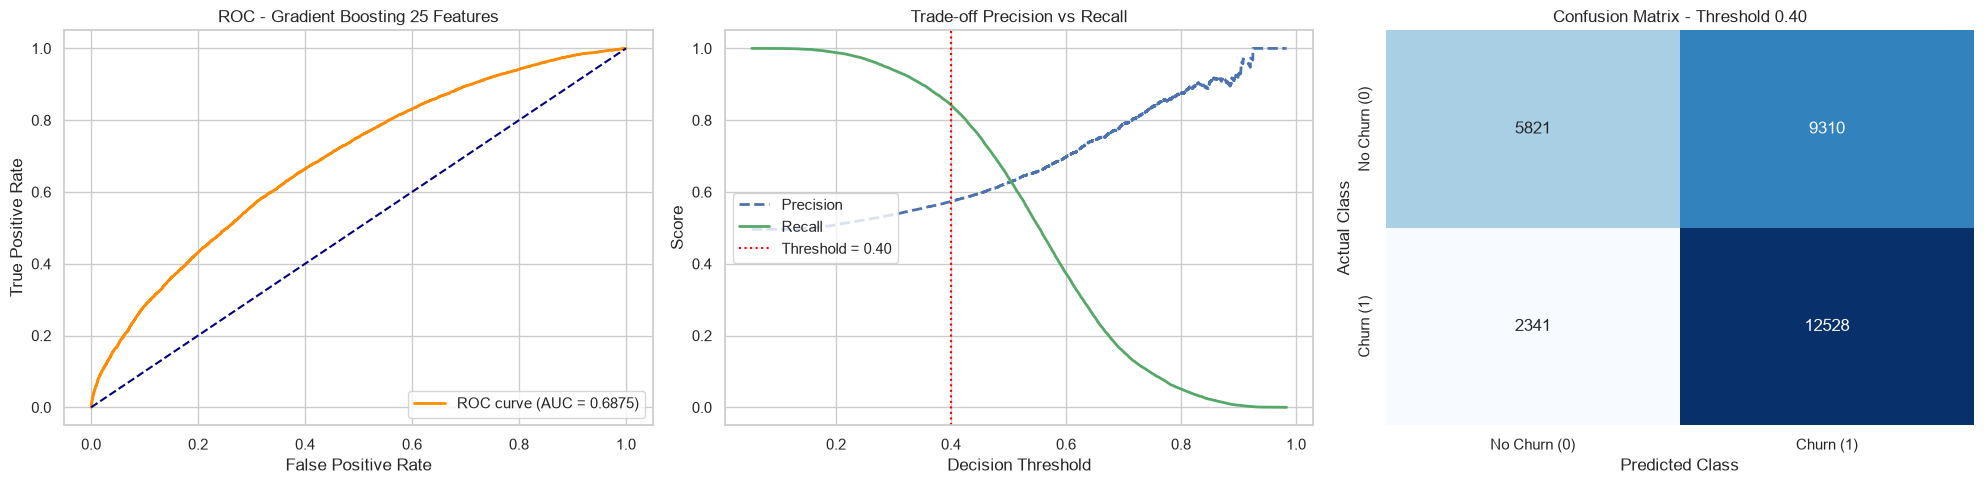

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    roc_auc_score
)

# Configurazione stile grafico
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(20, 5))


# ============================================================
# 1. CURVA ROC
# ============================================================

fpr, tpr, _ = roc_curve(
    y_test,
    y_proba_test_top
)

auc_score_test = roc_auc_score(
    y_test,
    y_proba_test_top
)

axes[0].plot(
    fpr,
    tpr,
    color='darkorange',
    lw=2,
    label=f'ROC curve (AUC = {auc_score_test:.4f})'
)

axes[0].plot(
    [0, 1],
    [0, 1],
    color='navy',
    lw=1.5,
    linestyle='--'
)

axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC - Gradient Boosting 25 Features')
axes[0].legend(loc='lower right')


# ============================================================
# 2. CURVA PRECISION-RECALL
# ============================================================

precisions, recalls, thresholds = precision_recall_curve(
    y_test,
    y_proba_test_top
)

axes[1].plot(
    thresholds,
    precisions[:-1],
    'b--',
    label='Precision',
    lw=2
)

axes[1].plot(
    thresholds,
    recalls[:-1],
    'g-',
    label='Recall',
    lw=2
)

# Threshold finale scelta sul validation set
axes[1].axvline(
    x=0.40,
    color='red',
    linestyle=':',
    label='Threshold = 0.40'
)

axes[1].set_xlabel('Decision Threshold')
axes[1].set_ylabel('Score')
axes[1].set_title('Trade-off Precision vs Recall')
axes[1].legend(loc='center left')


# ============================================================
# 3. CONFUSION MATRIX - THRESHOLD 0.40
# ============================================================

cm_40 = confusion_matrix(
    y_test,
    y_pred_test_top
)

sns.heatmap(
    cm_40,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[2],
    cbar=False,
    xticklabels=['No Churn (0)', 'Churn (1)'],
    yticklabels=['No Churn (0)', 'Churn (1)']
)

axes[2].set_xlabel('Predicted Class')
axes[2].set_ylabel('Actual Class')
axes[2].set_title('Confusion Matrix - Threshold 0.40')


plt.tight_layout()
plt.show()

### 14. Spiegabilità del Modello tramite SHAP (SHapley Additive exPlanations)
Utilizziamo la libreria **SHAP** per analizzare il contributo causale di ciascuna variabile sulle predizioni del modello:
- **Summary Plot (Beeswarm)**: Mostra l'impatto direzionale (se un valore alto/basso di una variabile aumenta o diminuisce la probabilità di Churn).
- **Bar Plot**: Classifica la rilevanza globale media assoluta di ciascuna variabile.

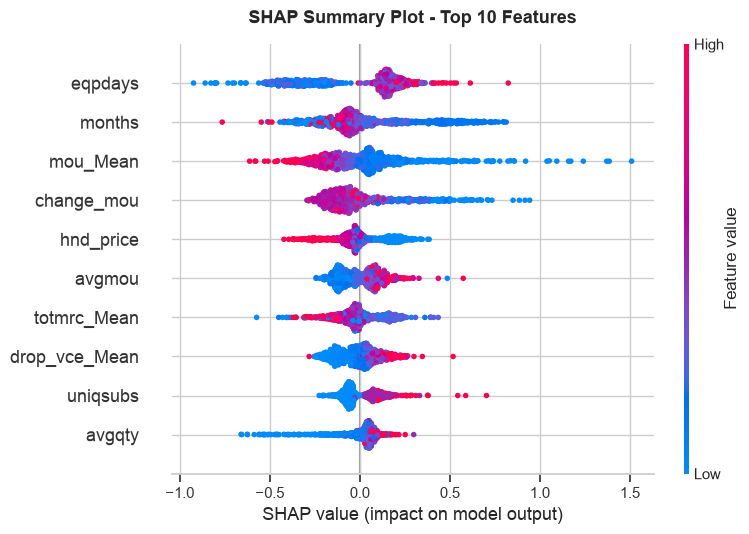

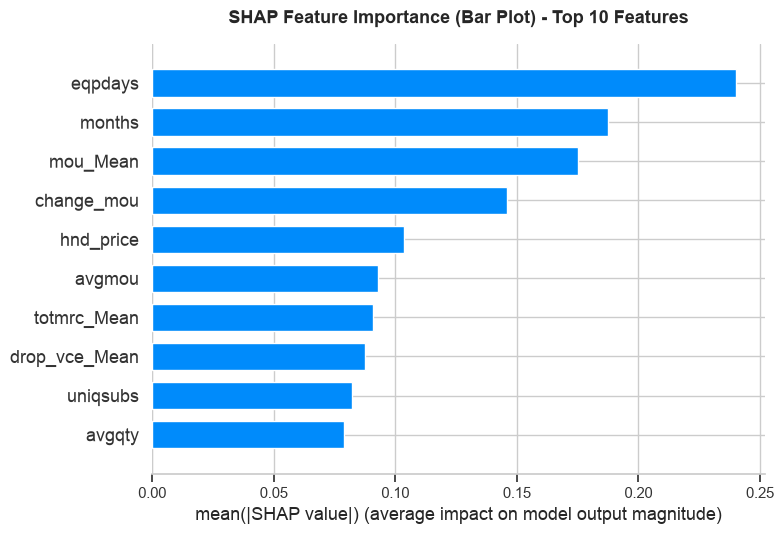

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

# ============================================================
# 1. PREPROCESSING DEL TEST SET (Top 25)
# ============================================================

X_test_mh = gb_top_pipeline.named_steps['missing_handler'].transform(X_test_top)
X_test_trans = gb_top_pipeline.named_steps['preprocessor'].transform(X_test_mh)

if hasattr(X_test_trans, 'toarray'):
    X_test_trans = X_test_trans.toarray()

raw_feature_names = gb_top_pipeline.named_steps['preprocessor'].get_feature_names_out()
clean_feature_names = [
    f.replace('num__', '').replace('cat__', '').replace('remainder__', '')
    for f in raw_feature_names
]

X_test_trans_df = pd.DataFrame(X_test_trans, columns=clean_feature_names)


# ============================================================
# 2. CALCOLO SHAP VALUES
# ============================================================

gb_model = gb_top_pipeline.named_steps['gb']
explainer = shap.TreeExplainer(gb_model)

rng = np.random.RandomState(42)
sample_size = min(1000, X_test_trans_df.shape[0])
sample_indices = rng.choice(X_test_trans_df.shape[0], size=sample_size, replace=False)

shap_sample_df = X_test_trans_df.iloc[sample_indices]
shap_values = explainer(shap_sample_df)


# ============================================================
# 3. SHAP SUMMARY PLOT (BEESWARM - TOP 10)
# ============================================================

plt.figure(figsize=(10, 6))
# max_display=10 nei summary_plot mostra le prime 10
shap.summary_plot(
    shap_values, 
    shap_sample_df, 
    max_display=10, 
    show=False
)
plt.title("SHAP Summary Plot - Top 10 Features", fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


# ============================================================
# 4. SHAP BAR PLOT (TOP 10 SENZA RIGA "SUM OF OTHERS")
# ============================================================

plt.figure(figsize=(10, 6))
# shap.plots.bar con max_display=11 include le 10 feature + eventuale resto, 
# oppure usiamo shap.summary_plot con plot_type='bar' che non crea la riga "Sum"
shap.summary_plot(
    shap_values, 
    shap_sample_df, 
    plot_type='bar', 
    max_display=10, 
    show=False
)
plt.title("SHAP Feature Importance (Bar Plot) - Top 10 Features", fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## PROVA REGRESSIONE LOGISTICA BASE SOLO PER ISPEZIONE

In [36]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

print("="*60)
print("--- TEST RAPIDO: REGRESSIONE LOGISTICA BASE (SOLO ISPEZIONE) ---")
print("="*60)

# ============================================================
# 1. RECUPERO DELLE TOP 25 FEATURE ED ESTRAZIONE SICURA
# ============================================================
# Se 'top_features' esiste usiamo quella, altrimenti la prendiamo da 'metadata'
if 'top_features' in locals():
    selected_cols = list(top_features)
elif 'metadata' in locals():
    selected_cols = metadata['features']
else:
    # Se per qualche motivo non sono in memoria, usiamo le prime 25 colonne di X_train
    selected_cols = X_train.columns[:25].tolist()

# Copia isolata dei dataset filtrati sulle 25 feature
X_tr_lr = X_train[selected_cols].copy()
X_te_lr = X_test[selected_cols].copy()
y_tr_lr = y_train.copy()
y_te_lr = y_test.copy()

# ============================================================
# 2. COSTRUZIONE PIPELINE LOGISTIC REGRESSION
# ============================================================
num_cols_lr = X_tr_lr.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_lr = X_tr_lr.select_dtypes(exclude=[np.number]).columns.tolist()

preprocessor_lr = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_cols_lr),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat_cols_lr)
    ]
)

lr_pipeline = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('lr', LogisticRegression(max_iter=1000, random_state=42))
])

# ============================================================
# 3. FIT & VALUTAZIONE SUL TEST SET
# ============================================================
lr_pipeline.fit(X_tr_lr, y_tr_lr)

y_proba_lr_test = lr_pipeline.predict_proba(X_te_lr)[:, 1]
y_pred_lr_040 = (y_proba_lr_test >= 0.40).astype(int)

auc_lr = roc_auc_score(y_te_lr, y_proba_lr_test)

print(f"\n[LR] ROC-AUC Test Set: {auc_lr:.4f}")
print("\n--- Report Classificazione Logistic Regression (Threshold 0.40) ---")
print(classification_report(y_te_lr, y_pred_lr_040, digits=4))

print("Confusion Matrix (Threshold 0.40):")
print(confusion_matrix(y_te_lr, y_pred_lr_040))
print("="*60)

# ============================================================
# 4. ISPEZIONE DEI COEFFICIENTI (RELAZIONI LINEARI)
# ============================================================
raw_names_lr = lr_pipeline.named_steps['preprocessor'].get_feature_names_out()
clean_names_lr = [
    f.replace('num__', '').replace('cat__', '') 
    for f in raw_names_lr
]

coefficients = lr_pipeline.named_steps['lr'].coef_[0]

df_coef = pd.DataFrame({
    'Feature': clean_names_lr,
    'Coefficient (Log-Odds)': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
}).sort_values(by='Abs_Coefficient', ascending=False)

print("\n--- Top 10 Feature per Impatto Lineare (Logistic Regression) ---")
display(df_coef[['Feature', 'Coefficient (Log-Odds)']].head(10))

--- TEST RAPIDO: REGRESSIONE LOGISTICA BASE (SOLO ISPEZIONE) ---

[LR] ROC-AUC Test Set: 0.6165

--- Report Classificazione Logistic Regression (Threshold 0.40) ---
              precision    recall  f1-score   support

           0     0.6639    0.2246    0.3357     15131
           1     0.5285    0.8843    0.6616     14869

    accuracy                         0.5516     30000
   macro avg     0.5962    0.5544    0.4986     30000
weighted avg     0.5968    0.5516    0.4972     30000

Confusion Matrix (Threshold 0.40):
[[ 3399 11732]
 [ 1721 13148]]

--- Top 10 Feature per Impatto Lineare (Logistic Regression) ---


,Feature,Coefficient (Log-Odds)
23,ethnic_C,-0.658427
55,crclscod_D5,-0.629935
71,crclscod_JF,0.615678
59,crclscod_E4,-0.490790
40,crclscod_A2,0.399106
64,crclscod_G,0.398535
48,crclscod_C5,-0.383913
32,ethnic_O,0.373805
22,ethnic_B,0.370094
2,mou_Mean,-0.337029
